# Agentic PFM image segmentation — prototype

One ReAct-style agent per task. It SEES a channel preview, then composes
basic image-analysis primitives (threshold / gradient / morphology …) to
produce a binary mask. Tools return NUMBERS; with `VISION_IN_LOOP=True`
the agent can also call `show_overlay()` to LOOK at its current mask.

Data source: cached previews in `src/spm_agent/.cashe/current/` (no instrument needed).
Everything here is standalone so it's easy to benchmark before integrating into the graph.

In [1]:
# --- Standard libs -----------------------------------------------------------
import io, os, base64
from pathlib import Path
from dataclasses import dataclass, field

In [6]:
# --- Scientific stack (all already in your .venv) ----------------------------
import numpy as np
from scipy import ndimage as ndi          # gaussian, sobel, morphology, labeling
from PIL import Image as PILImage

In [31]:
# --- LLM + graph -------------------------------------------------------------
from langchain_anthropic import ChatAnthropic
from langchain.agents import create_agent 
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

In [25]:
# --- Notebook display --------------------------------------------------------
from IPython.display import Image as IPyImage, display

# --- Load OPENAI_API_KEY from the repo .env ----------------------------------
from dotenv import load_dotenv
load_dotenv()                              # reads ../.env when notebook is in notebooks/
assert os.environ.get("ANTHROPIC_API_KEY"), "OPENAI_API_KEY not found in .env"
print("env loaded ok")

env loaded ok


In [5]:
# Folder holding cached channel previews (PNG). Matches your readfile_node output.
PREVIEW_DIR = Path("../src/spm_agent/.cashe/current").resolve()

# Where this prototype writes masks + overlays (kept separate from the repo cache).
OUT_DIR = Path("./seg_proto").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL          = "gpt-5.4"   # vision-capable; swap if needed
VISION_IN_LOOP = True        # True = agent can call show_overlay() and SEE its mask
MAX_SUPERSTEPS = 30          # recursion_limit guard (1 tool cycle ≈ 3 supersteps)

# Pick what to segment. Channel = a PNG filename stem in PREVIEW_DIR.
CHANNEL = "Phase1Retrace"                          # good for domain walls
TASK    = "ferroelectric domain wall segmentation"

print("available previews:", sorted(p.stem for p in PREVIEW_DIR.glob("*.png")))

available previews: ['Amplitude1Retrace', 'Amplitude2Retrace', 'Bias', 'Cur', 'Defl', 'FrequencyRetrace', 'HeightRetrace', 'Phase1Retrace', 'Phase2Retrace', 'Raw', 'ZSnsr']


In [51]:
MODEL      = "claude-sonnet-4-6"   # vision + tools; use "claude-opus-4-8" for the hard cases
MAX_TOKENS = 2048                  # Anthropic requires an explicit cap

cell 4

In [7]:
def _norm01(a):                       # NaN-aware min-max → [0,1]
    a = a.astype(np.float32)
    f = a[np.isfinite(a)]
    if f.size == 0: return np.zeros_like(a)
    lo, hi = float(f.min()), float(f.max())
    return np.zeros_like(a) if hi <= lo else (a - lo) / (hi - lo)

def _otsu(a01: np.ndarray) -> float:
    """Automatic threshold (Otsu) on a [0,1] image, pure numpy (no skimage)."""
    h, _ = np.histogram(a01[np.isfinite(a01)], bins=256, range=(0, 1))
    h = h.astype(float); total = h.sum()
    if total == 0:
        return 0.5
    p = h / total
    omega = np.cumsum(p)                                   # class-0 weight
    mu = np.cumsum(p * ((np.arange(256) + 0.5) / 256))     # class-0 mean
    mu_t = mu[-1]
    denom = omega * (1 - omega); denom[denom == 0] = 1e-12
    sigma_b2 = (mu_t * omega - mu) ** 2 / denom            # between-class variance
    return float((np.argmax(sigma_b2) + 0.5) / 256)

def to_view01(raw, p=(1, 99)):        # robust display image (what the model sees)
    f = raw[np.isfinite(raw)]
    lo, hi = np.percentile(f, p) if f.size else (0.0, 1.0)
    if hi <= lo: hi = lo + 1e-12
    return np.nan_to_num(np.clip((raw - lo) / (hi - lo), 0, 1))

@dataclass
class SegSession:
    """In-memory scratch buffer for ONE task. NOT a LangGraph state — it just
    holds the pixel data and is shared with the tools via a Python closure.
    The agent only ever sees numbers (and, if enabled, the overlay image)."""
    raw: np.ndarray                       # CHANGED: physical units, may hold NaN (absolute thresholds)
    view: np.ndarray
    work: np.ndarray                       # current working image (filters applied here)
    mask: np.ndarray                       # current boolean mask (the result so far)
    ops:  list = field(default_factory=list)   # ordered log of tool calls = the "program"
    want_view: bool = False                # set True when the agent calls show_overlay()

    @classmethod
    def from_raw(cls, raw):           # CHANGED: was from_image
        raw = raw.astype(np.float32)
        work = np.nan_to_num(_norm01(raw), nan=0.0)
        return cls(raw=raw, view=to_view01(raw), work=work.copy(),
                   mask=np.zeros(raw.shape, dtype=bool))

    def mask_stats(self):
        """Return (n_connected_regions, coverage_fraction) of the current mask."""
        _, n = ndi.label(self.mask)
        return int(n), float(self.mask.mean())

In [8]:
def render_overlay_datauri(view01, mask, max_px=256) -> str:   # CHANGED: takes the view
    rgb = (np.stack([view01] * 3, -1) * 255).astype(np.uint8)
    rgb[mask] = (0.4 * rgb[mask] + 0.6 * np.array([255, 0, 0])).astype(np.uint8)
    img = PILImage.fromarray(rgb); img.thumbnail((max_px, max_px))
    buf = io.BytesIO(); img.save(buf, format="JPEG", quality=80)
    return "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()

def save_mask_and_overlay(view01, mask, task, out_dir):        # CHANGED: view01 param name
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    mask_path, overlay_path = out_dir / f"{task}_mask.npy", out_dir / f"{task}_overlay.png"
    np.save(mask_path, mask.astype(np.uint8))
    rgb = (np.stack([view01] * 3, -1) * 255).astype(np.uint8)
    rgb[mask] = (0.4 * rgb[mask] + 0.6 * np.array([255, 0, 0])).astype(np.uint8)
    PILImage.fromarray(rgb).save(overlay_path)
    return str(mask_path), str(overlay_path)

In [29]:
def build_segmentation_tools(session: SegSession, vision_in_loop: bool) -> list:
    """Return the agent's instrument: small, orthogonal image-analysis ops.
    Each tool CLOSES OVER `session` (that's how it reaches the pixels without
    passing them through the LLM state), mutates work/mask, logs to ops,
    and returns NUMBERS ONLY."""

    @tool
    def describe_image() -> dict:
        """Intensity statistics of the current working image (shape, min/max/mean/std, p10/p90)."""
        w = session.work
        return {"shape": list(w.shape), "min": float(w.min()), "max": float(w.max()),
                "mean": float(w.mean()), "std": float(w.std()),
                "p10": float(np.percentile(w, 10)), "p90": float(np.percentile(w, 90))}

    @tool
    def smooth_image(sigma: float) -> dict:
        """Gaussian blur the working image to suppress noise. sigma in pixels (~1-3)."""
        session.work = _norm01(ndi.gaussian_filter(session.work, sigma=float(sigma)))
        session.ops.append({"op": "smooth", "sigma": sigma})
        return {"std": float(session.work.std())}

    @tool
    def compute_gradient_magnitude() -> dict:
        """Replace the working image with its Sobel gradient magnitude.
        Use for THIN BOUNDARY features (domain walls, grain boundaries)."""
        gx = ndi.sobel(session.work, axis=0); gy = ndi.sobel(session.work, axis=1)
        session.work = _norm01(np.hypot(gx, gy))
        session.ops.append({"op": "gradient_magnitude"})
        return {"mean": float(session.work.mean()), "max": float(session.work.max())}

    @tool
    def clean_mask(operation: str, size: int = 2) -> dict:
        """Morphological cleanup of the mask.
        operation: 'open' (drop specks) | 'close' (fill holes) | 'dilate' | 'erode'. size = element size."""
        st = np.ones((int(size), int(size)), dtype=bool)
        fn = {"open": ndi.binary_opening, "close": ndi.binary_closing,
              "dilate": ndi.binary_dilation, "erode": ndi.binary_erosion}[operation]
        session.mask = fn(session.mask, structure=st)
        session.ops.append({"op": "morphology", "operation": operation, "size": size})
        n, cov = session.mask_stats()
        return {"n_regions": n, "coverage": round(cov, 4)}

    @tool
    def remove_small_regions(min_pixels: int) -> dict:
        """Drop connected components smaller than min_pixels from the mask."""
        lbl, n = ndi.label(session.mask)
        if n:
            sizes = ndi.sum(np.ones_like(lbl), lbl, index=np.arange(1, n + 1))
            keep = [i + 1 for i, s in enumerate(sizes) if s >= int(min_pixels)]
            session.mask = np.isin(lbl, keep)
        session.ops.append({"op": "remove_small_regions", "min_pixels": min_pixels})
        n2, cov = session.mask_stats()
        return {"n_regions": n2, "coverage": round(cov, 4)}

    @tool
    def mask_summary() -> dict:
        """Current mask: region count, coverage, largest-region size in pixels."""
        lbl, n = ndi.label(session.mask)
        largest = int(ndi.sum(np.ones_like(lbl), lbl,
                      index=np.arange(1, n + 1)).max()) if n else 0
        return {"n_regions": int(n), "coverage": round(float(session.mask.mean()), 4),
                "largest_region_px": largest}

    @tool
    def threshold_image(method: str, value: float = 0.0, polarity: str = "above",
                        units: str = "normalized") -> dict:
        """Set the mask by thresholding.
        method: 'otsu' (auto) | 'percentile' (value=0-100) | 'absolute' (value in image units).
        units: 'normalized' = run on the processed [0,1] image;
               'absolute'   = run on RAW physical values → reproducible across files."""
        src = session.raw if units == "absolute" else session.work        # NEW
        if method == "otsu":
            t = _otsu(session.work)                                        # otsu only on normalized
        elif method == "percentile":
            t = float(np.nanpercentile(src, value))
        else:
            t = float(value)
        m = (src >= t) if polarity == "above" else (src <= t)
        session.mask = m & np.isfinite(src)                               # NaN never in mask
        session.ops.append({"op": "threshold", "method": method, "value": value,
                            "polarity": polarity, "units": units, "t": round(t, 4)})
        n, cov = session.mask_stats()
        return {"threshold": round(t, 4), "n_regions": n, "coverage": round(cov, 4)}

    @tool
    def reset_working_image() -> dict:
        """Restore the working image from raw and clear the mask."""
        session.work = np.nan_to_num(_norm01(session.raw), nan=0.0)        # CHANGED
        session.mask = np.zeros_like(session.mask)
        session.ops.append({"op": "reset"})
        return {"ok": True}

    tools = [describe_image, smooth_image, compute_gradient_magnitude, threshold_image,
             clean_mask, remove_small_regions, mask_summary, reset_working_image]

    # show_overlay is the ONLY tool that triggers an image injection (Cell 8).
    # It's added only in vision mode so numbers-only runs stay a clean ablation.
    if vision_in_loop:
        @tool
        def show_overlay() -> list:
            """Render the current mask over the channel image and return it so you can SEE it.
            Use when numeric feedback is ambiguous and you must visually confirm the mask
            matches the target feature before choosing the next operation."""
            session.ops.append({"op": "show_overlay"})
            n, cov = session.mask_stats()
            return [                                   # Claude reads images in tool results
                {"type": "text", "text": f"Overlay rendered. coverage={cov:.3f}, regions={n}."},
                {"type": "image_url",
                 "image_url": {"url": render_overlay_datauri(session.view, session.mask)}},
            ]
        tools.append(show_overlay)

    return tools

In [ ]:
def build_system_message(vision_in_loop: bool) -> SystemMessage:
    txt = (
        "You are an SPM/PFM segmentation agent doing BASIC image analysis. You get ONE channel "
        "image and ONE task: produce a binary mask using the tools. Compose primitives freely.\n"
        "- Thin BOUNDARY features (domain walls): compute_gradient_magnitude then threshold ('above').\n"
        "- REGION features (domains): smooth, threshold ('otsu'), clean with morphology.\n"
        "- threshold_image(units='absolute') thresholds RAW physical values — prefer it when you want "
        "a reproducible, file-independent mask.\n"
        "- Check mask_summary. Use <12 ops, then STOP and give "
        "one short paragraph: method, parameters, why."
    )
    if vision_in_loop:
        txt += "\n- You may call show_overlay() to SEE the current mask; use it sparingly."
    return SystemMessage(content=txt)

def build_human_message(task: str, session: SegSession) -> HumanMessage:   # CHANGED: takes session
    raw = session.raw; f = raw[np.isfinite(raw)]
    stats = (f"shape={raw.shape}, mean={f.mean():.3g}, std={f.std():.3g}, "
             f"p1={np.percentile(f,1):.3g}, p99={np.percentile(f,99):.3g}") if f.size else "no finite data"
    uri = render_overlay_datauri(session.view, np.zeros_like(session.mask))  # show the robust view
    return HumanMessage(content=[
        {"type": "text", "text": f"Segmentation task: {task}\n"
                                 f"Channel statistics (raw units): {stats}\n"
                                 f"Produce a binary mask of this feature using the tools."},
        {"type": "image_url", "image_url": {"url": uri}}])


In [15]:
import matplotlib.pyplot as plt
def load_preview01(stem: str) -> np.ndarray:
    """Load a cached channel preview PNG (grayscale) as a [0,1] float array."""
    a = np.asarray(PILImage.open(PREVIEW_DIR / f"{stem}.png").convert("L"), dtype=np.float32)
    return a / 255.0

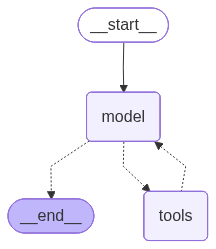

In [36]:
TASK, CHANNEL = "ferroelectric_domain_segmentation", "Phase1Retrace"

npy = PREVIEW_DIR / f"{CHANNEL}.npy"
raw = (np.load(npy).astype(np.float32) if npy.exists()
       else np.asarray(PILImage.open(PREVIEW_DIR / f"{CHANNEL}.png").convert("L"), np.float32))

session = SegSession.from_raw(raw)
tools   = build_segmentation_tools(session, VISION_IN_LOOP)
model   = ChatAnthropic(model=MODEL, temperature=0, max_tokens=MAX_TOKENS)

seg_agent = create_agent(model, tools, system_prompt=build_system_message(VISION_IN_LOOP))
seg_agent

In [49]:

from typing_extensions import TypedDict, NotRequired

class ChannelStats(TypedDict):
    min: float
    max: float
    mean: float
    std: float
    p01: float
    p99: float

class Channel(TypedDict):
    title: str
    units: str
    data_type: str
    shape: list
    preview_path: str
    array_path: str
    stats: ChannelStats

class SegmentationResult(TypedDict):
    task: str                 # joins back to channel_recommendations
    channel: str              # channel ID the agent worked on
    mask_path: str            # .npy boolean mask  (the pixels live here, not in state)
    overlay_path: str         # .png preview + red mask, for human/inspection
    n_regions: int            # connected components in the final mask
    coverage: float           # fraction of pixels masked (0..1)
    ops: list                 # ordered tool log = the reproducible "program"
    reasoning: str            # agent's final justification

class ImageAnalysisState(TypedDict):
    file_path: str
    file_channels: NotRequired[dict[str, Channel]]
    channel_recommendations: NotRequired[dict]
    segmentation_results: NotRequired[dict[str, SegmentationResult]] 

In [53]:
from spm_agent.utils.channel_utils import load_array

In [57]:
async def agentic_segmentation_node(state: ImageAnalysisState) -> ImageAnalysisState:
    recs     = state["channel_recommendations"]["task_recommendation"] # pyright: ignore[reportTypedDictNotRequiredAccess]
    channels = state["file_channels"]  # type: ignore
    model   = ChatAnthropic(model = MODEL, temperature=0, max_tokens=MAX_TOKENS)
    
    results = {}

    for rec in recs[:2]:
        if not rec["feasible"] or rec["primary_channel"] not in channels:
            continue
        task, channel_id = rec["task"], rec["primary_channel"]

        session = SegSession.from_raw(load_array(channels[channel_id].get("array_path")))
        agent   = create_agent(
            model,
            tools=build_segmentation_tools(session, VISION_IN_LOOP),
            system_prompt=build_system_message(VISION_IN_LOOP),
        )

        out = await agent.ainvoke(
            {"messages": [build_human_message(task, session)]},
            config={"recursion_limit": MAX_SUPERSTEPS},
        )

        # Claude returns content blocks → flatten to text
        final = out["messages"][-1].content
        final = final if isinstance(final, str) else " ".join(
            b.get("text", "") for b in final if isinstance(b, dict))
        
        mask_path, overlay_path = save_mask_and_overlay(session.view, session.mask, task, OUT_DIR)
        n_regions, coverage = session.mask_stats()

        results[task] = {
            "task": task, "channel": channel_id,
            "mask_path": mask_path, "overlay_path": overlay_path,
            "n_regions": n_regions, "coverage": round(coverage, 4),
            "ops": session.ops, "reasoning": final,
            "vision_in_loop": VISION_IN_LOOP, "model": MODEL,
            "n_look": sum(1 for o in session.ops if o["op"] == "show_overlay"),
        }

    return {"segmentation_results": results} # type: ignore
    


In [37]:
result = await seg_agent.ainvoke(
    {"messages": [build_human_message(TASK, session)]},
    config={"recursion_limit": MAX_SUPERSTEPS})

ops:
   {'op': 'smooth', 'sigma': 2.0}
   {'op': 'threshold', 'method': 'otsu', 'value': 0.0, 'polarity': 'above', 'units': 'normalized', 't': 0.3613}
   {'op': 'threshold', 'method': 'percentile', 'value': 45.0, 'polarity': 'above', 'units': 'normalized', 't': 0.1509}
   {'op': 'threshold', 'method': 'absolute', 'value': 100.0, 'polarity': 'above', 'units': 'absolute', 't': 100.0}
   {'op': 'threshold', 'method': 'absolute', 'value': 80.0, 'polarity': 'above', 'units': 'absolute', 't': 80.0}
   {'op': 'reset'}
   {'op': 'smooth', 'sigma': 2.0}
   {'op': 'threshold', 'method': 'percentile', 'value': 50.0, 'polarity': 'above', 'units': 'normalized', 't': 0.1705}
   {'op': 'morphology', 'operation': 'open', 'size': 2}
   {'op': 'morphology', 'operation': 'close', 'size': 3}
   {'op': 'remove_small_regions', 'min_pixels': 100}
   {'op': 'show_overlay'}

looks: 1

reasoning:
 The mask cleanly captures the bright ferroelectric domains (red) while excluding the dark domains and domain walls.

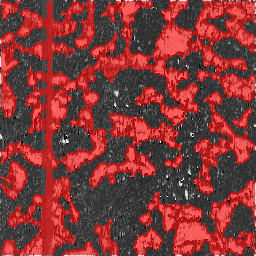

In [38]:
mask_path, overlay_path = save_mask_and_overlay(session.view, session.mask, TASK, OUT_DIR)

final = result["messages"][-1].content                 # Claude may return content blocks
final = final if isinstance(final, str) else " ".join(
    b.get("text", "") for b in final if isinstance(b, dict))

print("ops:"); [print("  ", o) for o in session.ops]
print(f"\nlooks: {sum(1 for o in session.ops if o['op']=='show_overlay')}")
print("\nreasoning:\n", final)
display(IPyImage(filename=overlay_path))

In [41]:
from pprint import pprint

{'messages': [HumanMessage(content=[{'type': 'text', 'text': 'Segmentation task: ferroelectric_domain_segmentation\nChannel statistics (raw units): shape=(256, 256), mean=73.2, std=58.8, p1=-15, p99=227\nProduce a binary mask of this feature using the tools.'}, {'type': 'image_url', 'image_url': {'url': ''}}], additional_kwargs={}, response_metadata={}, id='150bd4b6-e841-4947-aee5-b57f660a9c54'),
              AIMessage(content=[{'text': "I'll analyze this ferroelectric domain image and produce a binary mask. The image shows distinct bright and dark domains, so I'll use a region-based approach (smooth → threshold → clean).\n\n**Step 1: Describe the image and smooth it**", 'type': 'text'}, {'id': 'toolu_012piWN9yNSaocffPx3cKVQ5', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'describe_image', 'type': 'tool_use'}, {'id': 'toolu_01M1mUuazavtYuFVtm7WyueE', 'caller': {'type': 'direct'}, 'input': {'sigma': 2}, 'name': 'smooth_image', 'type': 'tool_use'}], additional_kwargs={}, response_
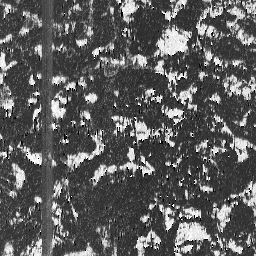
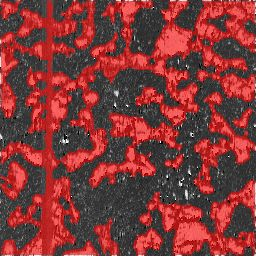

In [43]:
pprint(result)

In [58]:
from langgraph.graph import StateGraph, START, END

from spm_agent.nodes.readfile_node import readfile_node
from spm_agent.nodes.channel_recommendation_node import channel_recommendation_node

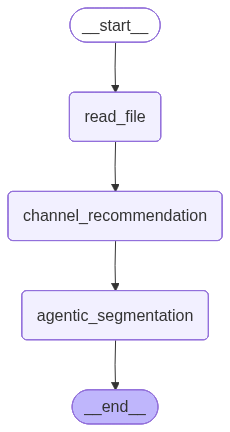

In [59]:
builder = StateGraph(ImageAnalysisState)
builder.add_node("read_file", readfile_node)
builder.add_node("channel_recommendation", channel_recommendation_node)
builder.add_node("agentic_segmentation", agentic_segmentation_node)

builder.add_edge(START, "read_file")
builder.add_edge("read_file", "channel_recommendation")
builder.add_edge("channel_recommendation", "agentic_segmentation")
builder.add_edge("agentic_segmentation", END)

im_graph = builder.compile()
im_graph

In [63]:
result = await im_graph.ainvoke(
    {
        "file_path": r"/Users/borisslautin/Documents/!!UTK/agentic_SPM/260618/PLZT_agent/PLZT_0000.ibw",
    }
)

In [64]:
result.keys()

dict_keys(['file_path', 'file_channels', 'channel_recommendations', 'segmentation_results'])

In [65]:
result['segmentation_results']

{'ferroelectric_domain_segmentation': {'task': 'ferroelectric_domain_segmentation', 'channel': 'Channel_004', 'mask_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/notebooks/seg_proto/ferroelectric_domain_segmentation_mask.npy', 'overlay_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/notebooks/seg_proto/ferroelectric_domain_segmentation_overlay.png', 'n_regions': 42, 'coverage': 0.2316, 'ops': [{'op': 'smooth', 'sigma': 2.0}, {'op': 'threshold', 'method': 'otsu', 'value': 0.0, 'polarity': 'below', 'units': 'normalized', 't': 0.5293}, {'op': 'morphology', 'operation': 'open', 'size': 3}, {'op': 'morphology', 'operation': 'close', 'size': 4}, {'op': 'remove_small_regions', 'min_pixels': 80}, {'op': 'show_overlay'}, {'op': 'morphology', 'operation': 'close', 'size': 5}, {'op': 'show_overlay'}], 'reasoning': "The mask cleanly delineates the dark ferroelectric domains. Here's a summary of the method:\n\n---\n\n**Method Summary:** This ferroelectric domain segmen